   badge_number            name  age  city_department_id
0           100      John Reese   42              101010
1           101    Harold Finch   60              202020
2           102  Jocelyn Carter   38              303030
3           103    Lionel Fusco   44              404040
4           104     Sameen Shaw   25              505050
   badge_number            name  age  city_department_id  Cluster
0           100      John Reese   42              101010        2
1           101    Harold Finch   60              202020        2
2           102  Jocelyn Carter   38              303030        0
3           103    Lionel Fusco   44              404040        0
4           104     Sameen Shaw   25              505050        1


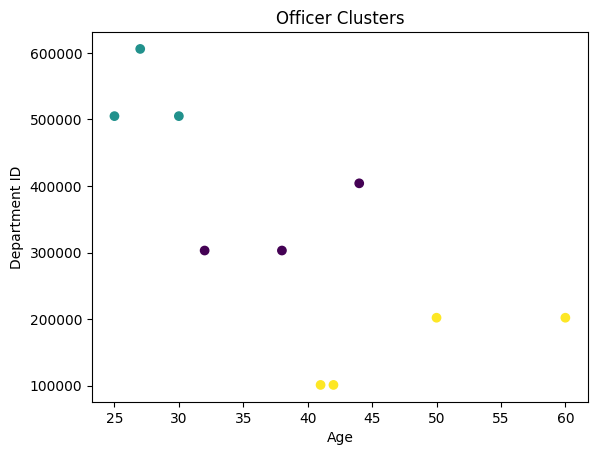

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('officers_data.csv')

print(data.head())

# Drop ID-like columns (not useful for clustering)
data_clean = data.drop(columns=['badge_number', 'name'])

# Encode categorical columns if needed
for col in data_clean.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data_clean[col] = le.fit_transform(data_clean[col])

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clean)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

data['Cluster'] = clusters

print(data.head())

# Plot clusters (age vs department as example)
plt.scatter(data['age'], data['city_department_id'], c=clusters)
plt.xlabel('Age')
plt.ylabel('Department ID')
plt.title('Officer Clusters')
plt.show()